# Model Training and Evaluation

Using cleaned dataset to train and compare models.

In [1]:
# loading cleaned data

import pandas as pd

print("loading processed data...")

df = pd.read_csv("processed_data.csv")

print("data loaded")
print("shape:", df.shape)

loading processed data...
data loaded
shape: (289846, 33)


In [2]:
# separating features and target

target = "loanriskcategory"

X = df.drop(target, axis=1)
y = df[target]

print("X shape:", X.shape)

X shape: (289846, 32)


In [3]:
# scaling features before training

from sklearn.preprocessing import StandardScaler

print("scaling data...")

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("scaling done")

scaling data...
scaling done


In [4]:
# splitting into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("data split done")

data split done


## Model Training
Training SVC, Logistic Regression, and Random Forest models.

In [5]:
# training SVC model (fast version for large data)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("training SVC (fast)...")

svc_model = LinearSVC()
svc_model.fit(X_train, y_train)

y_pred = svc_model.predict(X_test)

print("---- SVC ----")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

training SVC (fast)...
---- SVC ----
Accuracy: 0.8810246679316888
Precision: 0.8788604397279797
Recall: 0.8810246679316888
F1 Score: 0.8685535457687287


In [6]:
# training other models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("training additional models...")

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Random Forest
# training Random Forest (full strength but controlled)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("models trained")

training additional models...
models trained


## Model Comparison

Comparing performance of all trained models using accuracy metrics.

In [7]:
# comparing models

from sklearn.metrics import classification_report

print("\n--- MODEL COMPARISON ---")

acc_lr = accuracy_score(y_test, pred_lr)
print("\nLogistic Regression Accuracy:", acc_lr)

acc_rf = accuracy_score(y_test, pred_rf)
print("\nRandom Forest Accuracy:", acc_rf)

acc_svc = accuracy_score(y_test, y_pred)
print("\nSVC Accuracy:", acc_svc)

print("\n--- Detailed Report (Random Forest) ---")
print(classification_report(y_test, pred_rf))


--- MODEL COMPARISON ---

Logistic Regression Accuracy: 0.902742797998965

Random Forest Accuracy: 0.9994824909435915

SVC Accuracy: 0.8810246679316888

--- Detailed Report (Random Forest) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4004
           1       1.00      1.00      1.00     45236
           2       1.00      1.00      1.00      8730

    accuracy                           1.00     57970
   macro avg       1.00      1.00      1.00     57970
weighted avg       1.00      1.00      1.00     57970



## Feature Importance Analysis

Understanding which features influence the model predictions the most using Random Forest.

In [10]:
# feature importance using Random Forest

import pandas as pd

print("calculating feature importance...")

# getting importance values
importances = rf.feature_importances_

# getting feature names (important)
feature_names = df.drop("loanriskcategory", axis=1).columns

# creating dataframe
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# sorting
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)

print("top features:")
print(feature_importance_df.head(10))

calculating feature importance...
top features:
             feature  importance
5                dti    0.585272
0        creditscore    0.367174
12  monthsdelinquent    0.007177
7                ltv    0.005183
11    everdelinquent    0.004914
2                mip    0.004754
15   delinquencyflag    0.004456
4              ocltv    0.004001
6            origupb    0.003163
8   originterestrate    0.002698


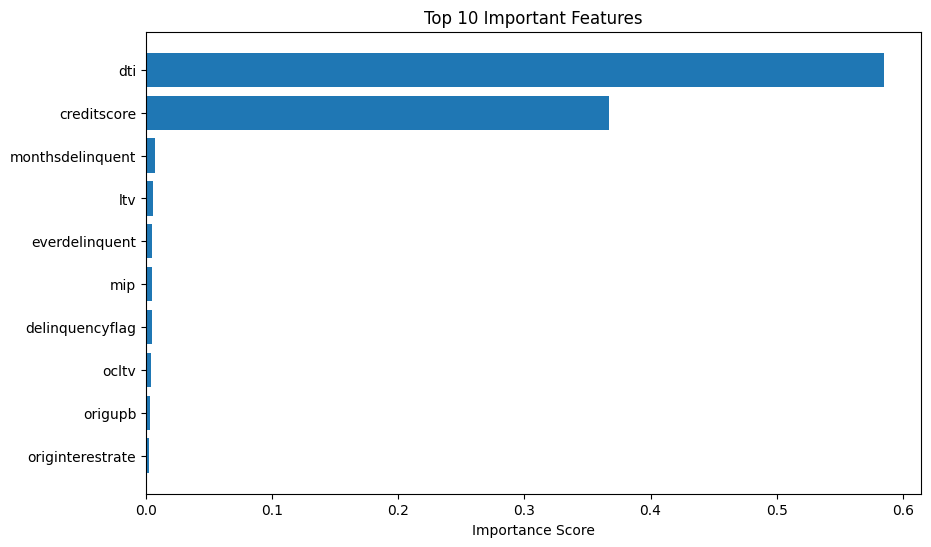

In [9]:
# plotting feature importance

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.show()

## Final Observations and Insights

### Model Performance

- Random Forest achieved extremely high accuracy (~99.95%), significantly outperforming other models.
- Logistic Regression showed good performance (~90%), but was less effective in capturing complex relationships.
- SVC (Linear) achieved lower accuracy (~88%), indicating limitations in modeling non-linear patterns.

### Feature Importance Insights (Based on Model Output)

- The most important feature is **DTI (Debt-to-Income ratio)** with a very high importance (~0.58).
- The second most important feature is **Credit Score** (~0.36), showing strong influence on loan risk.
- All other features have significantly lower importance values, indicating that:
  - A small number of features dominate the model decisions.
  - The model relies heavily on core financial indicators.

### Key Understanding

- Loan risk is primarily driven by **borrower financial health**, especially:
  - Debt burden (DTI)
  - Creditworthiness (Credit Score)
- Other variables like LTV, delinquency indicators, and loan amount contribute less but still support prediction.

### Important Observation

- The extremely high accuracy of Random Forest suggests:
  - The model fits the data very well
  - There may be potential overfitting due to strong dominance of a few features

### Practical Conclusion

- Random Forest is the best-performing model for this dataset.
- Feature importance provides clear interpretability of decision factors.
- This model can serve as a strong baseline for financial risk prediction systems.
- Future improvements could include validation on unseen data and model generalization checks.